# PyTorch DataLoader 튜토리얼

1. 왜 `Dataset` / `DataLoader`가 필요한가
2. 가장 쉬운 **tabular 데이터** 배치 만들기
3. `TensorDataset`과 `DataLoader`
4. **Custom Dataset** 직접 구현하기
5. tabular 데이터용 **transform / augmentation** 만들기
6. `collate_fn`으로 **배치 단위 augmentation (MixUp)** 하기
7. 아주 쉬운 **synthetic image dataset** 만들기
8. image 데이터용 **augmentation** 만들기
9. 실제 학습 루프에서 DataLoader가 어떻게 쓰이는가

---

In [28]:
import math
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch
from PIL import Image, ImageDraw, ImageEnhance

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print('torch version:', torch.__version__)
print('seed fixed:', SEED)

torch version: 2.4.1+cu124
seed fixed: 42


## 1. 큰 그림: `Dataset`과 `DataLoader`

- **Dataset**: `i`번째 샘플을 주는 객체
- **DataLoader**: Dataset에서 여러 샘플을 꺼내 **batch** 로 만들어 주는 객체

즉,

> Dataset은 “한 개 샘플 접근 규칙”, DataLoader는 “여러 샘플을 묶어 반복하는 규칙”

입니다.


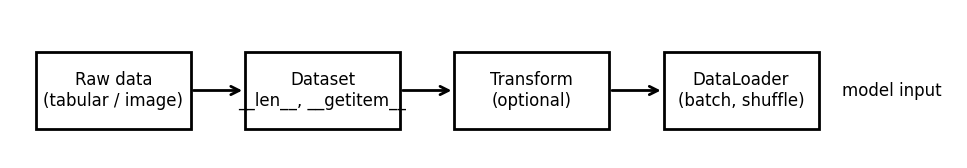

## 2. 정말 제일 쉬운 예시: Python 리스트를 손으로 batch 만들기

`DataLoader`가 하는 일을 먼저 **직접 손으로** 해보겠습니다.


In [30]:
data = list(range(10))
batch_size = 4

manual_batches = []
for start in range(0, len(data), batch_size):
    batch = data[start:start + batch_size]
    manual_batches.append(batch)

manual_batches

[[0, 1, 2, 3], [4, 5, 6, 7], [8, 9]]

이 코드가 하는 일은 단순합니다.

- 데이터: `[0, 1, 2, ..., 9]`
- `batch_size=4`
- 결과: `[[0,1,2,3], [4,5,6,7], [8,9]]`

이게 바로 DataLoader의 핵심 기능 중 하나입니다.

그런데 딥러닝에서는 보통 다음이 더 필요합니다.

- 매 epoch마다 **shuffle**
- label도 함께 묶기
- tensor로 바꾸기
- image / tabular / text 등 다양한 타입 처리
- custom transform, augmentation

그래서 `Dataset`과 `DataLoader`를 씁니다.


# Part A. Tabular 데이터로 시작하기

먼저 가장 이해하기 쉬운 **2차원 tabular 분류 문제**를 만들겠습니다.

- 입력 feature: `x1`, `x2`
- label: `y` (0 또는 1)


In [31]:
n_per_class = 120
class0 = np.random.randn(n_per_class, 2) * 0.7 + np.array([-2.0, -1.5])
class1 = np.random.randn(n_per_class, 2) * 0.8 + np.array([2.0, 1.8])

X_all = np.vstack([class0, class1]).astype(np.float32)
y_all = np.array([0] * n_per_class + [1] * n_per_class, dtype=np.int64)

print('X_all shape:', X_all.shape)
print('y_all shape:', y_all.shape)
print('first 5 labels:', y_all[:5])

X_all shape: (240, 2)
y_all shape: (240,)
first 5 labels: [0 0 0 0 0]


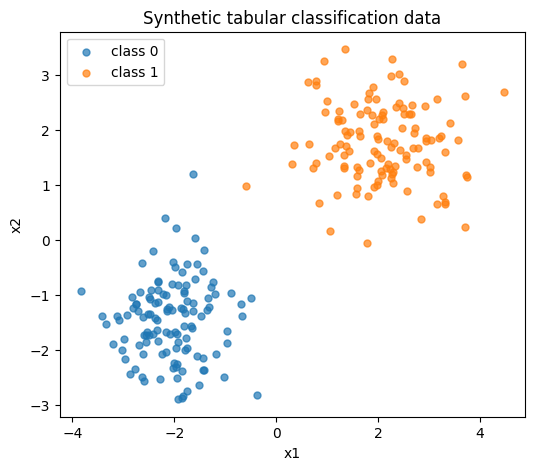

In [32]:
plt.figure(figsize=(6, 5))
plt.scatter(X_all[y_all == 0, 0], X_all[y_all == 0, 1], s=25, alpha=0.7, label='class 0')
plt.scatter(X_all[y_all == 1, 0], X_all[y_all == 1, 1], s=25, alpha=0.7, label='class 1')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.title('Synthetic tabular classification data')
plt.show()

## 3. `TensorDataset` + `DataLoader`

가장 빠르게 시작하는 방법은 `TensorDataset`입니다.

- 이미 `X`, `y`가 tensor 혹은 배열 형태로 준비되어 있다면
- `TensorDataset(X, y)` 로 매우 쉽게 dataset을 만들 수 있습니다.


In [39]:
X_tensor = torch.tensor(X_all)
y_tensor = torch.tensor(y_all)

tabular_tensor_ds = TensorDataset(X_tensor, y_tensor)
print('dataset length:', len(tabular_tensor_ds))
print('sample 0:', tabular_tensor_ds[0])
print('sample 1:', tabular_tensor_ds[1])
print('sample last:', tabular_tensor_ds[-1])

dataset length: 240
sample 0: (tensor([-1.6523, -1.5968]), tensor(0))
sample 1: (tensor([-1.5466, -0.4339]), tensor(0))
sample last: (tensor([4.4631, 2.6957]), tensor(1))


In [42]:
tabular_tensor_ds[0][0], tabular_tensor_ds[0][1]

(tensor([-1.6523, -1.5968]), tensor(0))

In [43]:
tabular_loader = DataLoader(
    tabular_tensor_ds,
    batch_size=8,
    shuffle=True,
)

batch_x, batch_y = next(iter(tabular_loader))
print('batch_x shape:', batch_x.shape)
print('batch_y shape:', batch_y.shape)
print('batch_y:', batch_y.tolist())

batch_x shape: torch.Size([8, 2])
batch_y shape: torch.Size([8])
batch_y: [0, 0, 1, 1, 0, 0, 0, 0]


- Dataset에서 꺼내는 것은 보통 **샘플 하나**
- DataLoader에서 꺼내는 것은 보통 **batch 하나**

즉,

- `dataset[0]` → `(feature_한개, label_한개)`
- `next(iter(loader))` → `(feature_여러개, label_여러개)`


## 4. `batch_size`, `shuffle`, `drop_last`를 아주 작은 데이터로 보기

작은 숫자 데이터로 **순서가 어떻게 바뀌는지** 직접 확인해 봅시다.


In [44]:
small_ds = TensorDataset(torch.arange(10))

def show_batches(batch_size=4, shuffle=False, drop_last=False):
    loader = DataLoader(small_ds, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last)
    batches = []
    for (b,) in loader:
        batches.append(b.tolist())
    return batches

print('shuffle=False, drop_last=False')
print(show_batches(batch_size=4, shuffle=False, drop_last=False))
print()
print('shuffle=True, drop_last=False')
print(show_batches(batch_size=4, shuffle=True, drop_last=False))
print()
print('shuffle=False, drop_last=True')
print(show_batches(batch_size=4, shuffle=False, drop_last=True))

shuffle=False, drop_last=False
[[0, 1, 2, 3], [4, 5, 6, 7], [8, 9]]

shuffle=True, drop_last=False
[[8, 3, 4, 1], [0, 6, 5, 9], [7, 2]]

shuffle=False, drop_last=True
[[0, 1, 2, 3], [4, 5, 6, 7]]


정리:

- `batch_size=4`: 한 번에 4개씩 묶음
- `shuffle=True`: 순서를 섞음
- `drop_last=True`: 마지막 batch가 4개보다 작으면 버림

예를 들어 데이터가 10개이고 `batch_size=4`면

- `drop_last=False` → `[4, 4, 2]`
- `drop_last=True` → `[4, 4]`

가 됩니다.


## 5. 이제 `Custom Dataset`을 직접 만들어보자

실무에서는 데이터가 보통 딱 `TensorDataset` 형태로 깔끔하지 않습니다.

예를 들면,
- feature 외에 sample id도 주고 싶을 수 있고
- `dict` 형태로 반환하고 싶을 수 있고
- transform을 중간에 넣고 싶을 수 있습니다.

그래서 `Dataset`을 상속받아 `__len__`, `__getitem__`을 직접 구현하는 연습이 중요합니다.


In [46]:
class TabularClassificationDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = np.asarray(X, dtype=np.float32)
        self.y = np.asarray(y, dtype=np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        sample = {
            'features': self.X[idx].copy(),
            'label': self.y[idx],
            'index': idx,
        }
        if self.transform is not None:
            sample = self.transform(sample)
        return sample

plain_tabular_ds = TabularClassificationDataset(X_all, y_all)
plain_tabular_ds[0]

{'features': array([-1.6523001, -1.5967851], dtype=float32),
 'label': 0,
 'index': 0}

In [47]:
plain_loader = DataLoader(plain_tabular_ds, batch_size=4, shuffle=False)
plain_batch = next(iter(plain_loader))

print(type(plain_batch))
for k, v in plain_batch.items():
    print(k, type(v), getattr(v, 'shape', None))
print('\nlabels:', plain_batch['label'])

<class 'dict'>
features <class 'torch.Tensor'> torch.Size([4, 2])
label <class 'torch.Tensor'> torch.Size([4])
index <class 'torch.Tensor'> torch.Size([4])

labels: tensor([0, 0, 0, 0])


`Dataset`이 `dict`를 반환해도, `DataLoader`는 기본적으로 **같은 key끼리 모아서 batch dict**를 만듭니다.

즉,
- 샘플 하나: `{'features': [..], 'label': 1, 'index': 7}`
- 배치 하나: `{'features': [B, ...], 'label': [B], 'index': [B]}`

처럼 바뀝니다.


## 6. train / valid split

실전에서는 보통 하나의 dataset을 train / validation으로 나눕니다.

합성 데이터에서도 같은 패턴을 그대로 써보겠습니다.


In [48]:
full_ds = TabularClassificationDataset(X_all, y_all)
train_size = int(len(full_ds) * 0.8)
valid_size = len(full_ds) - train_size

train_ds_plain, valid_ds_plain = random_split(
    full_ds,
    [train_size, valid_size],
    generator=torch.Generator().manual_seed(SEED),
)

print('train size:', len(train_ds_plain))
print('valid size:', len(valid_ds_plain))

train size: 192
valid size: 48


## 7. tabular 데이터용 transform / augmentation

이미지에서는 augmentation이 익숙하지만, tabular에서도 간단한 augmentation을 넣을 수 있습니다.

여기서는 다음을 직접 구현해 보겠습니다.

- `ToTensor`: numpy → torch tensor
- `Standardize`: 평균/표준편차로 정규화
- `AddGaussianNoise`: feature에 작은 noise 추가
- `RandomFeatureMask`: 일부 feature를 확률적으로 0으로 만들기
- `Compose`: 여러 transform 연결

> 포인트: **transform은 보통 샘플 하나 단위**로 적용됩니다.


In [49]:
class Compose:
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, sample):
        for t in self.transforms:
            sample = t(sample)
        return sample


class Standardize:
    def __init__(self, mean, std, eps=1e-6):
        self.mean = np.asarray(mean, dtype=np.float32)
        self.std = np.asarray(std, dtype=np.float32)
        self.eps = eps

    def __call__(self, sample):
        x = sample['features']
        x = (x - self.mean) / (self.std + self.eps)
        sample = dict(sample)
        sample['features'] = x.astype(np.float32)
        return sample


class AddGaussianNoise:
    def __init__(self, std=0.1, p=0.5):
        self.std = std
        self.p = p

    def __call__(self, sample):
        x = sample['features']
        if np.random.rand() < self.p:
            noise = np.random.randn(*x.shape).astype(np.float32) * self.std
            x = x + noise
        sample = dict(sample)
        sample['features'] = x.astype(np.float32)
        return sample


class RandomFeatureMask:
    def __init__(self, p=0.3):
        self.p = p

    def __call__(self, sample):
        x = sample['features']
        mask = (np.random.rand(*x.shape) > self.p).astype(np.float32)
        sample = dict(sample)
        sample['features'] = (x * mask).astype(np.float32)
        sample['mask'] = mask.astype(np.float32)
        return sample


class ToTensor:
    def __call__(self, sample):
        sample = dict(sample)
        sample['features'] = torch.tensor(sample['features'], dtype=torch.float32)
        sample['label'] = torch.tensor(sample['label'], dtype=torch.long)
        sample['index'] = torch.tensor(sample['index'], dtype=torch.long)
        if 'mask' in sample:
            sample['mask'] = torch.tensor(sample['mask'], dtype=torch.float32)
        return sample

In [50]:
train_indices = train_ds_plain.indices
X_train_np = X_all[train_indices]
mean = X_train_np.mean(axis=0)
std = X_train_np.std(axis=0)

print('train mean:', mean)
print('train std :', std)

train mean: [0.00242028 0.13034648]
train std : [2.2405865 1.7917808]


In [51]:
train_transform = Compose([
    Standardize(mean, std),
    AddGaussianNoise(std=0.15, p=0.8),
    RandomFeatureMask(p=0.2),
    ToTensor(),
])

valid_transform = Compose([
    Standardize(mean, std),
    ToTensor(),
])

train_ds = TabularClassificationDataset(X_all[train_indices], y_all[train_indices], transform=train_transform)
valid_indices = valid_ds_plain.indices
valid_ds = TabularClassificationDataset(X_all[valid_indices], y_all[valid_indices], transform=valid_transform)

sample_a = train_ds[0]
sample_b = train_ds[0]

print('same index, two calls with augmentation')
print('sample_a:', sample_a)
print('sample_b:', sample_b)

same index, two calls with augmentation
sample_a: {'features': tensor([-1.0955, -1.6448]), 'label': tensor(0), 'index': tensor(0), 'mask': tensor([1., 1.])}
sample_b: {'features': tensor([-0.0000, -1.4385]), 'label': tensor(0), 'index': tensor(0), 'mask': tensor([0., 1.])}


같은 `train_ds[0]`을 두 번 불러도 결과가 조금씩 달라질 수 있습니다.

이유는 training augmentation이 **랜덤하게** 들어가기 때문입니다.

즉,
- train dataset: augmentation ON
- valid/test dataset: augmentation OFF

패턴이 일반적입니다.


In [52]:
rows = []
raw_ds_for_compare = TabularClassificationDataset(X_all[train_indices], y_all[train_indices], transform=None)
for i in range(5):
    raw = raw_ds_for_compare[i]
    aug = train_ds[i]
    rows.append({
        'idx': i,
        'raw_x1': float(raw['features'][0]),
        'raw_x2': float(raw['features'][1]),
        'aug_x1': float(aug['features'][0]),
        'aug_x2': float(aug['features'][1]),
        'label': int(aug['label']),
    })

pd.DataFrame(rows)

,idx,raw_x1,raw_x2,aug_x1,aug_x2,label
0,0,-2.964369,-2.156477,-1.165812,-0.000000,0
1,1,-0.894551,-0.962796,-0.171860,-0.000000,0
2,2,1.797945,0.801773,1.010723,0.178278,1
3,3,-2.511257,-1.348479,-1.121883,-0.825338,0
4,4,3.302892,0.695919,0.000000,0.000000,1


## 8. DataLoader로 train / valid batch 만들기


In [53]:
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=16, shuffle=False)

train_batch = next(iter(train_loader))
for k, v in train_batch.items():
    print(k, v.shape, v.dtype)
print('\nfirst 5 labels:', train_batch['label'][:5])

features torch.Size([16, 2]) torch.float32
label torch.Size([16]) torch.int64
index torch.Size([16]) torch.int64
mask torch.Size([16, 2]) torch.float32

first 5 labels: tensor([0, 0, 1, 1, 1])


## 9. 실제 학습 루프에서는 이렇게 쓴다

`DataLoader`를 만들고 나서도 “그 다음에 뭐하지?”에서 멈춥니다.

그래서 아주 짧은 tabular 분류 학습 루프를 한 번 보겠습니다.


In [54]:
class TinyMLP(nn.Module):
    def __init__(self, in_dim=2, hidden_dim=16, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, features):
        return self.net(features)


def evaluate_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in loader:
            batch_features = batch['features']
            batch_labels = batch['label']
            logits = model(batch_features)
            pred = logits.argmax(dim=1)
            correct += (pred == batch_labels).sum().item()
            total += batch_labels.numel()
    return correct / total

model = TinyMLP()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.02)

for epoch in range(2):
    model.train()
    running_loss = 0.0
    for batch in train_loader:
        batch_features = batch['features']
        batch_labels = batch['label']

        optimizer.zero_grad()
        logits = model(batch_features)
        loss = criterion(logits, batch_labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_acc = evaluate_accuracy(model, train_loader)
    valid_acc = evaluate_accuracy(model, valid_loader)
    print(f'epoch={epoch+1:02d} | loss={running_loss/len(train_loader):.4f} | train_acc={train_acc:.3f} | valid_acc={valid_acc:.3f}')

epoch=01 | loss=0.5230 | train_acc=0.984 | valid_acc=1.000
epoch=02 | loss=0.1635 | train_acc=0.979 | valid_acc=1.000


여기서 핵심은 사실 모델이 아니라 이 줄입니다.

```python
for batch in train_loader:
```

즉, DataLoader는 **학습 루프가 먹기 좋은 형태로 batch를 반복해서 공급**합니다.


## 10. batch 단위 augmentation: `collate_fn`으로 MixUp 넣기

augmentation은 **샘플 하나 단위**였습니다.

그런데 어떤 augmentation은 **batch 전체를 본 뒤** 적용하는 것이 더 자연스럽습니다.
대표적인 예가 **MixUp** 입니다.

`collate_fn`은 Dataset이 꺼낸 샘플 여러 개를 받아서 **최종 batch를 어떻게 만들지** 정의합니다.


In [56]:
base_train_transform = Compose([
    Standardize(mean, std),
    ToTensor(),
])
base_train_ds = TabularClassificationDataset(X_all[train_indices], y_all[train_indices], transform=base_train_transform)

def mixup_collate(batch, alpha=0.4, num_classes=2):
    features = torch.stack([item['features'] for item in batch], dim=0)
    labels = torch.stack([item['label'] for item in batch], dim=0).long()

    labels_onehot = torch.nn.functional.one_hot(labels, num_classes=num_classes).float()

    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    perm = torch.randperm(features.size(0))

    mixed_features = lam * features + (1 - lam) * features[perm]
    mixed_labels = lam * labels_onehot + (1 - lam) * labels_onehot[perm]

    return {
        'features': mixed_features,
        'soft_label': mixed_labels,
        'lambda': torch.tensor(lam, dtype=torch.float32),
        'perm': perm,
    }

mixup_loader = DataLoader(
    base_train_ds,
    batch_size=8,
    shuffle=True,
    collate_fn=mixup_collate,
)

mix_batch = next(iter(mixup_loader))
print('features shape:', mix_batch['features'].shape)
print('soft_label shape:', mix_batch['soft_label'].shape)
print('lambda:', float(mix_batch['lambda']))
print('first 3 soft labels:', mix_batch['soft_label'][:3], sep='\n')

features shape: torch.Size([8, 2])
soft_label shape: torch.Size([8, 2])
lambda: 0.42142874002456665
first 3 soft labels:
tensor([[0.5786, 0.4214],
        [0.0000, 1.0000],
        [0.4214, 0.5786]])


요점:

- `Dataset`은 여전히 샘플 하나씩 반환
- `collate_fn`이 샘플 여러 개를 받아 **특별한 batch**를 만듦
- 그래서 MixUp처럼 **배치 단위 로직**을 넣기 좋음

즉 augmentation을 넣는 위치는 크게 두 군데입니다.

1. `Dataset.__getitem__` 혹은 sample transform: **샘플 단위**
2. `collate_fn`: **배치 단위**


# Part B. Synthetic Image Dataset 만들기

이제 이미지 데이터로 넘어가겠습니다.

외부 파일 없이도 이해할 수 있도록, 우리가 직접 **도형 이미지(circle / square / triangle)** 를 생성해 보겠습니다.

- image: 64x64 RGB
- class 0: square
- class 1: circle
- class 2: triangle


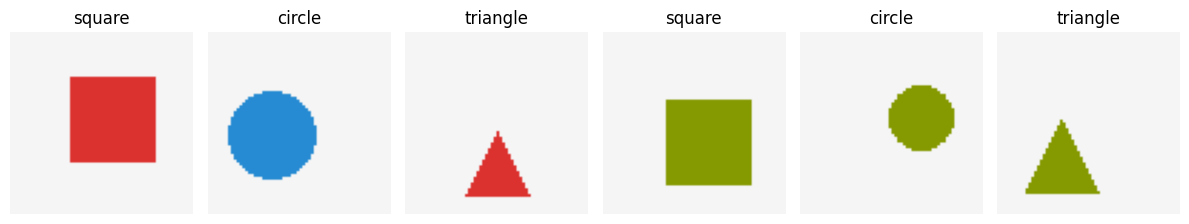

In [57]:
LABEL_TO_NAME = {0: 'square', 1: 'circle', 2: 'triangle'}


def make_shape_image(label, image_size=64, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    bg_color = (245, 245, 245)
    img = Image.new('RGB', (image_size, image_size), color=bg_color)
    draw = ImageDraw.Draw(img)

    color_choices = [(220, 50, 47), (38, 139, 210), (133, 153, 0), (211, 54, 130)]
    shape_color = color_choices[int(rng.integers(0, len(color_choices)))]

    size = int(rng.integers(image_size // 3, image_size // 2))
    x0 = int(rng.integers(6, image_size - size - 6))
    y0 = int(rng.integers(6, image_size - size - 6))
    x1, y1 = x0 + size, y0 + size

    if label == 0:
        draw.rectangle([x0, y0, x1, y1], fill=shape_color)
    elif label == 1:
        draw.ellipse([x0, y0, x1, y1], fill=shape_color)
    elif label == 2:
        p1 = (x0 + size // 2, y0)
        p2 = (x0, y1)
        p3 = (x1, y1)
        draw.polygon([p1, p2, p3], fill=shape_color)
    else:
        raise ValueError('label must be 0, 1, or 2')

    return img


fig, axes = plt.subplots(1, 6, figsize=(12, 2.5))
rng = np.random.default_rng(SEED)
for i, ax in enumerate(axes):
    label = i % 3
    img = make_shape_image(label, rng=rng)
    ax.imshow(img)
    ax.set_title(LABEL_TO_NAME[label])
    ax.axis('off')
plt.tight_layout()
plt.show()

## 11. Image Dataset 구현

이번에는 dataset 내부에서 **필요할 때마다 이미지를 생성**하도록 만들겠습니다.

즉,
- dataset 길이: `num_samples`
- `__getitem__(idx)`가 호출되면
- `idx`를 seed처럼 사용해서 **항상 같은 synthetic 이미지**를 만들어 냄

이 방식의 장점은:
- 별도 이미지 파일 저장이 필요 없음
- notebook만으로 실습 가능
- 재현성 확보 가능


In [58]:
class SyntheticShapesDataset(Dataset):
    def __init__(self, num_samples=300, image_size=64, transform=None, indices=None):
        self.image_size = image_size
        self.transform = transform
        self.indices = list(range(num_samples)) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        original_idx = self.indices[idx]
        label = original_idx % 3
        rng = np.random.default_rng(SEED + original_idx)
        image = make_shape_image(label, image_size=self.image_size, rng=rng)

        sample = {
            'image': image,
            'label': label,
            'index': original_idx,
        }
        if self.transform is not None:
            sample = self.transform(sample)
        return sample

image_plain_ds = SyntheticShapesDataset(num_samples=9, image_size=64, transform=None)
first_img_sample = image_plain_ds[0]
first_img_sample['image'], first_img_sample['label'], first_img_sample['index']

(<PIL.Image.Image image mode=RGB size=64x64>, 0, 0)

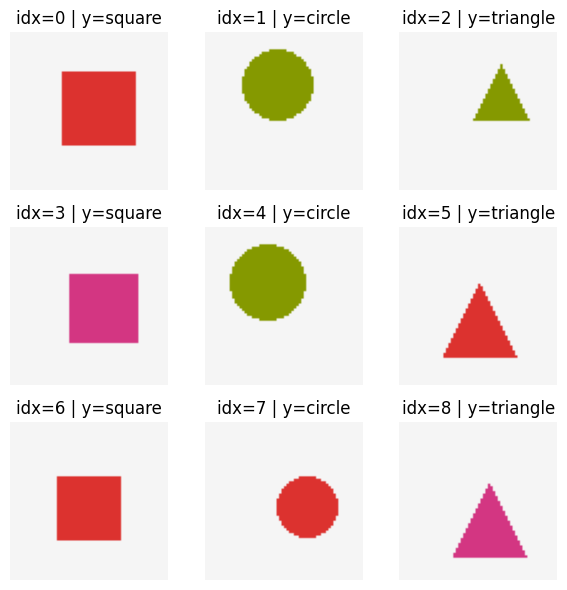

In [59]:
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
for i, ax in enumerate(axes.ravel()):
    sample = image_plain_ds[i]
    ax.imshow(sample['image'])
    ax.set_title(f"idx={sample['index']} | y={LABEL_TO_NAME[sample['label']]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

## 12. image transform / augmentation 직접 구현하기

이번에도 `torchvision`을 바로 쓰기보다, 원리를 보이기 위해 아주 단순한 버전을 직접 만들어 보겠습니다.

구현할 것:

- `ImageToTensor`: PIL image → torch tensor `[C, H, W]`
- `RandomHorizontalFlip`
- `RandomRotate`
- `RandomBrightness`
- `RandomCutout`
- `Compose`

이렇게 직접 만들어 보면,

> augmentation도 결국 “샘플 하나를 받아서 조금 바꾸고 다시 반환하는 함수”

라는 점이 명확해집니다.


In [60]:
class ImageToTensor:
    def __call__(self, sample):
        img = np.array(sample['image']).astype(np.float32) / 255.0
        img = np.transpose(img, (2, 0, 1))
        sample = dict(sample)
        sample['image'] = torch.tensor(img, dtype=torch.float32)
        sample['label'] = torch.tensor(sample['label'], dtype=torch.long)
        sample['index'] = torch.tensor(sample['index'], dtype=torch.long)
        return sample


class RandomHorizontalFlip:
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, sample):
        img = sample['image']
        if np.random.rand() < self.p:
            img = img.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
        sample = dict(sample)
        sample['image'] = img
        return sample


class RandomRotate:
    def __init__(self, degrees=20):
        self.degrees = degrees

    def __call__(self, sample):
        angle = np.random.uniform(-self.degrees, self.degrees)
        img = sample['image'].rotate(angle, fillcolor=(245, 245, 245))
        sample = dict(sample)
        sample['image'] = img
        return sample


class RandomBrightness:
    def __init__(self, min_factor=0.7, max_factor=1.3):
        self.min_factor = min_factor
        self.max_factor = max_factor

    def __call__(self, sample):
        factor = np.random.uniform(self.min_factor, self.max_factor)
        img = ImageEnhance.Brightness(sample['image']).enhance(factor)
        sample = dict(sample)
        sample['image'] = img
        return sample


class RandomCutout:
    def __init__(self, p=0.5, cutout_size=12):
        self.p = p
        self.cutout_size = cutout_size

    def __call__(self, sample):
        img = sample['image'].copy()
        if np.random.rand() < self.p:
            draw = ImageDraw.Draw(img)
            w, h = img.size
            cx = np.random.randint(0, w)
            cy = np.random.randint(0, h)
            half = self.cutout_size // 2
            x0 = max(0, cx - half)
            y0 = max(0, cy - half)
            x1 = min(w, cx + half)
            y1 = min(h, cy + half)
            draw.rectangle([x0, y0, x1, y1], fill=(245, 245, 245))
        sample = dict(sample)
        sample['image'] = img
        return sample

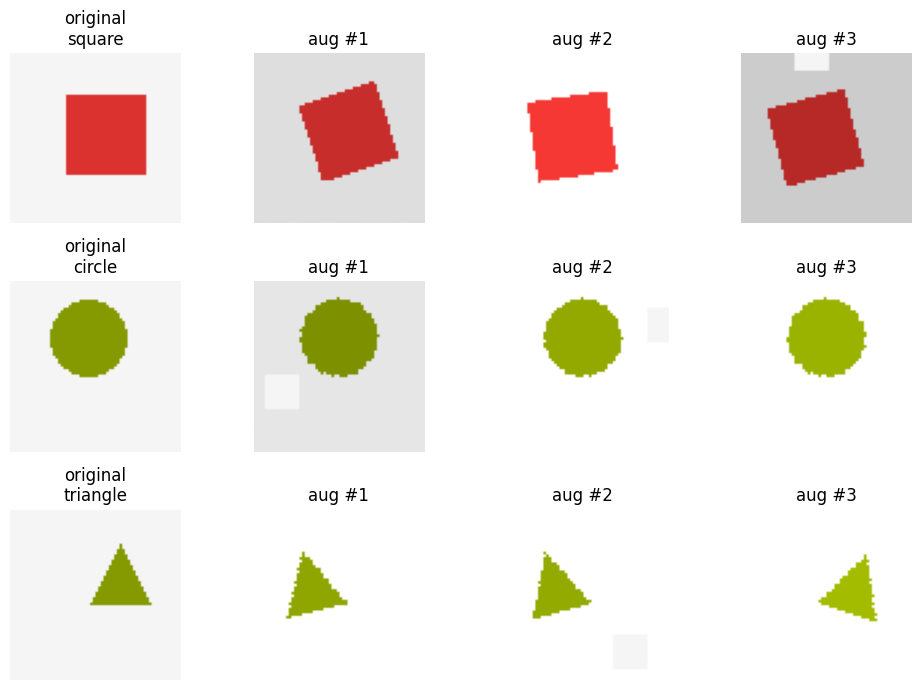

In [61]:
image_train_transform = Compose([
    RandomHorizontalFlip(p=0.5),
    RandomRotate(degrees=20),
    RandomBrightness(0.75, 1.25),
    RandomCutout(p=0.6, cutout_size=12),
    ImageToTensor(),
])

image_eval_transform = Compose([
    ImageToTensor(),
])

image_aug_ds = SyntheticShapesDataset(num_samples=9, image_size=64, transform=image_train_transform)

fig, axes = plt.subplots(3, 4, figsize=(10, 7))
base_plain_ds = SyntheticShapesDataset(num_samples=3, image_size=64, transform=None)
for row in range(3):
    base = base_plain_ds[row]
    axes[row, 0].imshow(base['image'])
    axes[row, 0].set_title(f"original\n{LABEL_TO_NAME[base['label']]}")
    axes[row, 0].axis('off')
    for col in range(1, 4):
        aug = image_aug_ds[row]
        img = aug['image'].permute(1, 2, 0).numpy()
        axes[row, col].imshow(img)
        axes[row, col].set_title(f'aug #{col}')
        axes[row, col].axis('off')
plt.tight_layout()
plt.show()

위 결과를 보면,
같은 원본 샘플도 train transform 때문에 호출할 때마다 조금씩 달라질 수 있습니다.

## 13. Image DataLoader 만들기


In [62]:
full_image_ds = SyntheticShapesDataset(num_samples=300, image_size=64, transform=None)
img_train_size = int(0.8 * len(full_image_ds))
img_valid_size = len(full_image_ds) - img_train_size
img_train_subset, img_valid_subset = random_split(
    full_image_ds,
    [img_train_size, img_valid_size],
    generator=torch.Generator().manual_seed(SEED),
)

img_train_indices = img_train_subset.indices
img_valid_indices = img_valid_subset.indices

img_train_ds = SyntheticShapesDataset(indices=img_train_indices, image_size=64, transform=image_train_transform)
img_valid_ds = SyntheticShapesDataset(indices=img_valid_indices, image_size=64, transform=image_eval_transform)

print('image train size:', len(img_train_ds))
print('image valid size:', len(img_valid_ds))

image train size: 240
image valid size: 60


위처럼 `indices`를 dataset에 직접 넘기면,

- train / valid split이 분리되고
- 원본 synthetic 샘플의 index도 그대로 유지됩니다.

실전에서 이미지 파일 경로 리스트를 train / valid로 나누는 패턴과 거의 같은 구조라고 생각하면 됩니다.


In [63]:
image_train_loader = DataLoader(img_train_ds, batch_size=12, shuffle=True)
image_valid_loader = DataLoader(img_valid_ds, batch_size=12, shuffle=False)

image_batch = next(iter(image_train_loader))
print('image batch shape:', image_batch['image'].shape)
print('label batch shape:', image_batch['label'].shape)
print('index batch shape:', image_batch['index'].shape)

image batch shape: torch.Size([12, 3, 64, 64])
label batch shape: torch.Size([12])
index batch shape: torch.Size([12])


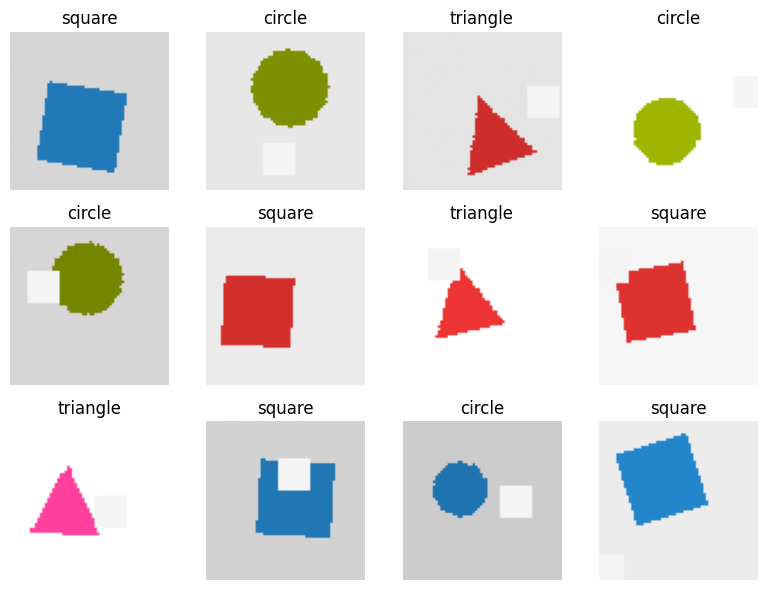

In [64]:
fig, axes = plt.subplots(3, 4, figsize=(8, 6))
for ax, img, label in zip(axes.ravel(), image_batch['image'][:12], image_batch['label'][:12]):
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(LABEL_TO_NAME[int(label)])
    ax.axis('off')
plt.tight_layout()
plt.show()

## 14. image 분류에서 DataLoader가 한 번의 학습 step에 들어가는 모습

이번에는 아주 작은 CNN으로 **정말 짧게** 한 번의 학습 step만 보여주겠습니다.

중요한 것은 성능이 아니라,

- batch image shape가 `[B, C, H, W]`라는 점
- DataLoader에서 꺼낸 batch를 그대로 모델에 넣고 loss를 계산한다는 점

입니다.


In [65]:
class TinyImageMLP(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 64 * 64, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, images):
        return self.net(images)

image_model = TinyImageMLP(num_classes=3)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(image_model.parameters(), lr=0.003)

batch = next(iter(image_train_loader))
batch_images = batch['image']
batch_labels = batch['label']

optimizer.zero_grad()
logits = image_model(batch_images)
loss = criterion(logits, batch_labels)
loss.backward()
optimizer.step()

pred = logits.argmax(dim=1)
acc = (pred == batch_labels).float().mean().item()

print('one training step completed')
print('logits shape:', logits.shape)
print('loss:', float(loss))
print('batch accuracy:', round(acc, 3))

one training step completed
logits shape: torch.Size([12, 3])
loss: 1.0585004091262817
batch accuracy: 0.5


# Part C. 자주 묻는 질문과 실전 팁

## 15. 언제 `TensorDataset`을 쓰고, 언제 `Custom Dataset`을 쓰나?

### `TensorDataset`이 좋은 경우
- 이미 데이터가 깔끔하게 tensor로 준비되어 있음
- 추가 정보(sample id, path, mask 등)가 필요 없음
- 간단한 실험을 빨리 하고 싶음

### `Custom Dataset`이 좋은 경우
- 파일을 읽어 와야 함
- 반환 형태를 `dict`로 만들고 싶음
- transform / augmentation이 필요함
- image path, text, timestamp, meta 정보 등을 함께 다루고 싶음

---

## 16. augmentation은 어디에 넣는가?

### 샘플 단위 augmentation
보통 `Dataset.__getitem__` 내부 transform에서 처리

예:
- image flip, rotate, brightness
- tabular noise, feature masking

### 배치 단위 augmentation
보통 `collate_fn`에서 처리

예:
- MixUp
- CutMix
- batch-wise masking

---

## 17. `shuffle=True`는 train에서만 쓰는가?

일반적으로
- **train loader**: `shuffle=True`
- **valid/test loader**: `shuffle=False`

를 사용합니다.

이유:
- train은 순서를 섞는 것이 일반화에 도움될 수 있음
- valid/test는 평가를 안정적으로 하고 싶음

---

## 18. `num_workers`, `pin_memory`는?

실무에서는 DataLoader에 아래 옵션도 자주 붙습니다.

```python
DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)
```

아주 간단히 말하면,
- `num_workers`: 데이터를 미리 준비하는 worker 프로세스 수
- `pin_memory`: GPU 전송을 조금 더 빠르게 돕는 옵션
- 해당내용은 공식 문서 참고(!)


## 19. 선택 학습: `torchvision.transforms.v2`

image augmentation을 직접 만들기보다 `torchvision`을 자주 씁니다.

예를 들면 아래와 같은 느낌입니다.

```python
from torchvision.transforms import v2

train_tf = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(20),
    v2.ColorJitter(brightness=0.2),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])
```

공식 문서:
- PyTorch Data tutorial
- `torch.utils.data.DataLoader`
- Torchvision transforms v2


## 20. 연습문제

### 문제 토픽 A
1. tabular 데이터의 `batch_size`를 8, 32로 바꿔 batch shape를 비교해 보세요.
2. `shuffle=False`로 바꾸면 첫 번째 batch의 label 순서가 어떻게 달라지나요?
3. `drop_last=True`를 넣으면 마지막 batch는 어떻게 되나요?

### 문제 토픽 B
4. tabular augmentation에서 `AddGaussianNoise(std=0.5)`로 바꾸면 학습이 어떻게 달라질까요?
5. image augmentation에서 `RandomCutout`을 끄면 validation accuracy가 어떻게 달라질까요?
6. `Dataset`이 tuple 대신 dict를 반환할 때 장점은 무엇일까요?

### 문제 토픽 C
7. `SyntheticShapesDataset`에 class 3으로 **star** 도형을 추가해 보세요.
8. `collate_fn`에서 MixUp 대신 **CutMix 비슷한 로직**을 직접 설계해 보세요.
9. image dataset이 `(image, label, path)` 비슷한 구조를 반환하게 바꾸어 보세요.
